In [ ]:
!pip install kagglehub
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("akaiinu/crema-d")

print("Path to dataset files:", path)
print("Số lượng file:", len(os.listdir(path+'/cremad/Image-01-FPS')))
import os, glob, pandas as pd

root_dir = path+"/cremad/Image-01-FPS"
rows = []
print(os.listdir(root_dir))
for folder in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    # tách nhãn cảm xúc từ tên folder
    parts = folder.split("_")
    if len(parts) < 3:
        continue
    emotion = parts[2]  # ví dụ: ANG, HAP, SAD, NEU, FEA, DIS...

    # lấy tất cả ảnh trong folder đó
    for img_path in glob.glob(os.path.join(folder_path, "*.jpg")):
        rows.append([img_path, emotion])

df = pd.DataFrame(rows, columns=["image_path", "emotion"])
print("Số lượng ảnh:", len(df))
print("Các nhãn:", sorted(df["emotion"].unique()))
df.head()

emotions = sorted(df["emotion"].unique())
emo2idx = {emo: i for i, emo in enumerate(emotions)}
df["label"] = df["emotion"].map(emo2idx)
print(emo2idx)



from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class EmotionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path, label = self.df.iloc[idx][["image_path", "label"]]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label





Using Colab cache for faster access to the 'crema-d' dataset.
Path to dataset files: /kaggle/input/crema-d
Số lượng file: 7442
['1022_MTI_HAP_XX', '1014_TAI_FEA_XX', '1070_TIE_SAD_XX', '1080_DFA_FEA_XX', '1012_TAI_NEU_XX', '1064_TIE_NEU_XX', '1084_IWW_HAP_XX', '1082_MTI_FEA_XX', '1034_IEO_SAD_MD', '1044_IWW_FEA_XX', '1014_TSI_ANG_XX', '1006_TAI_NEU_XX', '1082_WSI_NEU_XX', '1006_ITS_FEA_XX', '1010_MTI_DIS_XX', '1030_IWW_HAP_XX', '1042_IWL_SAD_XX', '1085_ITH_NEU_XX', '1053_IEO_FEA_MD', '1075_MTI_FEA_XX', '1005_IEO_HAP_LO', '1055_IWL_DIS_XX', '1011_IWL_HAP_XX', '1030_TAI_DIS_XX', '1050_IWL_ANG_XX', '1067_TAI_NEU_XX', '1008_DFA_FEA_XX', '1072_IEO_HAP_MD', '1076_IWW_ANG_XX', '1088_TIE_NEU_XX', '1027_ITS_DIS_XX', '1014_IEO_ANG_LO', '1050_IEO_HAP_HI', '1066_ITS_SAD_XX', '1015_IEO_FEA_LO', '1049_IWL_HAP_XX', '1006_WSI_DIS_XX', '1054_WSI_SAD_XX', '1081_ITS_HAP_XX', '1067_DFA_SAD_XX', '1004_WSI_HAP_XX', '1016_IOM_NEU_XX', '1046_DFA_ANG_XX', '1001_TAI_HAP_XX', '1027_ITH_DIS_XX', '1043_IWW_ANG_XX'

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
train_loader = DataLoader(EmotionDataset(train_df, transform), batch_size=64, shuffle=True)
val_loader   = DataLoader(EmotionDataset(val_df, transform), batch_size=64)
!pip install torch tdqm


In [ ]:
# =============================================================================
# PHẦN 1: CHUẨN BỊ DỮ LIỆU (DATA PREPARATION)
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import numpy as np

# 1.1. Sửa lỗi Data Leakage: Chia tập Train/Val dựa trên Actor ID
# Lấy ID diễn viên từ tên file (Ví dụ: 1006_TAI_NEU_XX -> ID là 1006)
# Giả định df đã có cột 'image_path' từ phần code trước của bạn
df['actor_id'] = df['image_path'].apply(lambda x: os.path.basename(x).split('_')[0])

unique_actors = df['actor_id'].unique()
train_actors, val_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)

print(f"Tổng số diễn viên: {len(unique_actors)}")
print(f"Train actors: {len(train_actors)} | Val actors: {len(val_actors)}")

# Tạo DataFrame riêng biệt
train_df = df[df['actor_id'].isin(train_actors)].reset_index(drop=True)
val_df = df[df['actor_id'].isin(val_actors)].reset_index(drop=True)

print(f"Số ảnh Train: {len(train_df)} | Số ảnh Val: {len(val_df)}")

# 1.2. Định nghĩa Transforms (Tăng cường dữ liệu mạnh mẽ cho Train)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Resize về chuẩn ResNet
    transforms.RandomHorizontalFlip(p=0.5), # Lật ảnh ngẫu nhiên
    transforms.RandomRotation(10),       # Xoay nhẹ +/- 10 độ
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Chỉnh sáng/tương phản
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Chỉ resize chuẩn
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1.3. Khởi tạo Dataset và DataLoader
# (Sử dụng class EmotionDataset bạn đã định nghĩa ở cell trước)
train_dataset = EmotionDataset(train_df, transform=train_transform)
val_dataset = EmotionDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
# =============================================================================
# Trích xuất đặc trưng (Feature Extraction)
# Chúng ta sẽ lấy đầu ra từ lớp trước lớp fc (thường là sau lớp Global Average Pooling) của ResNet-18 đã huấn luyện.

#
# =============================================================================
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

def extract_deep_features(model, loader, device):
    model.eval()
    features = []
    labels_list = []

    # Tạo một mô hình phụ chỉ lấy đến lớp avgpool
    # Chúng ta loại bỏ lớp fc cuối cùng
    feature_extractor = torch.nn.Sequential(*(list(model.children())[:-1]))

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting Deep Features"):
            imgs = imgs.to(device)
            # Output shape: (batch, 512, 1, 1) cho ResNet18
            feat = feature_extractor(imgs)
            # Flatten thành vector 512 chiều
            feat = feat.view(feat.size(0), -1)

            features.append(feat.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.concatenate(features), np.concatenate(labels_list)


import torch.nn as nn
from torchvision import models

import torch.nn as nn
from torchvision import models

# =============================================================================
# PHẦN 2: XÂY DỰNG MODEL RESNET50 (TRANSFER LEARNING – IMAGENET1K_V2)
# =============================================================================

import torch.nn as nn
from torchvision import models

def build_resnet50_finetune_layer4(num_classes):
    # 1. Load ImageNet-1K V2
    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V2
    )

    # 2. Freeze toàn bộ
    for param in model.parameters():
        param.requires_grad = False

    # 3. Unfreeze layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # 4. Thay FC head
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, 512),     # theo báo cáo là 512
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)    # theo báo cáo là 512
    )

    return model




# Khởi tạo model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Số class dựa trên dữ liệu của bạn (thường là 6 hoặc 7)
# num_classes = len(unique_actors) if 'unique_actors' not in locals() else 6
# Lưu ý: Sửa lại số 6 cứng nếu bạn biết chắc chắn số emotion, code trên lấy ví dụ an toàn

num_classes = 6

print(f"Đang khởi tạo model Fine-tune Layer 4 trên: {device}")
model = build_resnet50_finetune_layer4(num_classes).to(device)

optimizer = optim.Adam([
    {
        # Nhóm 1: Layer 4 (Backbone) -> Học rất chậm để bảo toàn kiến thức cũ
        'params': model.layer4.parameters(),
        'lr': 1e-5  # 0.00001
    },
    {
        # Nhóm 2: FC Layers (Head) -> Học nhanh hơn vì mới khởi tạo ngẫu nhiên
        'params': model.fc.parameters(),
        'lr': 1e-3  # 0.001
    }
])

criterion = nn.CrossEntropyLoss()

num_epochs = 60  # ❌ KHÔNG NÊN 100, mình giải thích bên dưới
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

# 1. Khởi tạo Scheduler
# Giảm LR đi 10 lần nếu Val Loss không cải thiện sau 3 epochs
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)


history = [] # Nơi lưu trữ Acc, Loss, F1, LR qua từng epoch
best_val_loss = float('inf')

print(f"Bắt đầu huấn luyện {num_epochs} epochs...")


best_val_f1 = 0.0

for epoch in range(num_epochs):
    # --- PHASE: TRAINING ---
    model.train()
    train_loss, train_preds, train_labels = 0.0, [], []

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    # --- PHASE: VALIDATION ---
    model.eval()
    val_loss, val_preds, val_labels = 0.0, [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # 2. Tính toán các chỉ số (Metrics)
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')
    val_recall = recall_score(val_labels, val_preds, average='weighted')
    val_precision = precision_score(val_labels, val_preds, average='weighted')

    # Lấy Learning Rate hiện tại (từ nhóm tham số của Head)
    current_lr = optimizer.param_groups[1]['lr']

    # 3. Cập nhật Scheduler dựa trên Val Loss
    scheduler.step(avg_val_loss)

    # 4. Lưu lại lịch sử
    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'val_recall': val_recall,
        'val_precision': val_precision,
        'lr': current_lr
    })

    print(f"Epoch {epoch+1}: Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f} | LR: {current_lr}")


    # 5. Lưu Checkpoint (Mô hình tốt nhất)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_resnet50_emotion.pth')
        print("--> Đã lưu mô hình tốt nhất!")

    # val_f1 = f1_score(val_labels, val_preds, average='weighted')

    # if val_f1 > best_val_f1:
    #     best_val_f1 = val_f1
    #     torch.save(model.state_dict(), 'best_resnet50_f1.pth')
    #     print("--> Saved best model based on F1-score")


# Chuyển history thành DataFrame để dễ quản lý
# history_df = pd.DataFrame(history)



history_df = pd.DataFrame(history)
history_df.to_csv("training_history_resnet50_mlp.csv", index=False)




Tổng số diễn viên: 64
Train actors: 51 | Val actors: 13
Số ảnh Train: 15842 | Số ảnh Val: 7457
Đang khởi tạo model Fine-tune Layer 4 trên: cuda
Bắt đầu huấn luyện 60 epochs...


Epoch 1 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 1: Val Loss: 1.6234 | Val Acc: 0.3092 | F1: 0.2416 | LR: 0.001
--> Đã lưu mô hình tốt nhất!


Epoch 2 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

...

Epoch 59 [Val]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 59: Val Loss: 0.9428 | Val Acc: 0.6622 | F1: 0.6595 | LR: 1.0000000000000004e-08


Epoch 60 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 60 [Val]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 60: Val Loss: 0.9587 | Val Acc: 0.6578 | F1: 0.6530 | LR: 1.0000000000000004e-08


In [ ]:
model.load_state_dict(torch.load('best_resnet50_emotion.pth'))
model.eval()



# Bước 1: Trích xuất đặc trưng từ Train và Val
print("--- Đang trích xuất đặc trưng từ ResNet-50 ---")
X_train_feat, y_train_feat = extract_deep_features(model, train_loader, device)
X_val_feat, y_val_feat = extract_deep_features(model, val_loader, device)






# Bước 2: Chuẩn hóa dữ liệu (Cực kỳ quan trọng đối với SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)

# Bước 3: Huấn luyện SVM với Kernel RBF (Phi tuyến)
print("--- Đang huấn luyện SVM (Kernel RBF) ---")
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_classifier.fit(X_train_scaled, y_train_feat)

# Bước 4: Dự đoán và đánh giá
y_pred_svm = svm_classifier.predict(X_val_scaled)

print("\n📊 SVM EVALUATION ON RESNET-50 FEATURES")
print(classification_report(y_val_feat, y_pred_svm, target_names=emotions, digits=4))


--- Đang trích xuất đặc trưng từ ResNet-50 ---


Extracting Deep Features:   0%|          | 0/248 [00:00<?, ?it/s]

Extracting Deep Features:   0%|          | 0/117 [00:00<?, ?it/s]

--- Đang huấn luyện SVM (Kernel RBF) ---

📊 SVM EVALUATION ON RESNET-50 FEATURES
              precision    recall  f1-score   support

         ANG     0.6151    0.5252    0.5666      1272
         DIS     0.7265    0.8412    0.7797      1285
         FEA     0.6257    0.6011    0.6132      1271
         HAP     0.7791    0.8489    0.8125      1271
         NEU     0.5715    0.6473    0.6071      1086
         SAD     0.5148    0.4237    0.4649      1272

    accuracy                         0.6482      7457
   macro avg     0.6388    0.6479    0.6406      7457
weighted avg     0.6406    0.6482    0.6417      7457



In [ ]:
import joblib

joblib.dump(svm_classifier, "svm_rbf.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

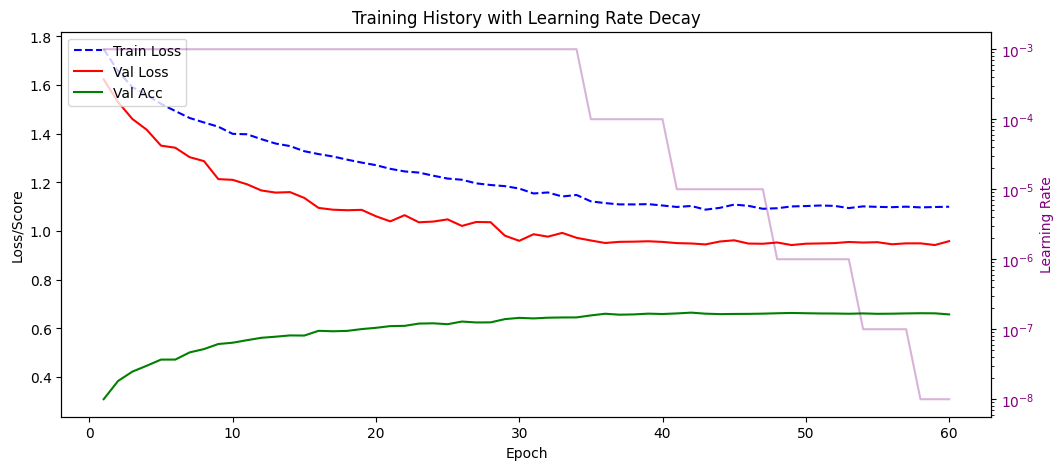

--- Đang trích xuất đặc trưng từ ResNet-50 (Best Model) ---


Extracting Deep Features:   0%|          | 0/248 [00:00<?, ?it/s]

Extracting Deep Features:   0%|          | 0/117 [00:00<?, ?it/s]

--- Đang huấn luyện SVM (Kernel RBF) trên vector 2048 chiều ---

📊 HYBRID DCNN-SVM EVALUATION REPORT
              precision    recall  f1-score   support

         ANG     0.6243    0.5134    0.5634      1272
         DIS     0.7235    0.8389    0.7769      1285
         FEA     0.6493    0.5681    0.6060      1271
         HAP     0.7942    0.8348    0.8140      1271
         NEU     0.5577    0.6501    0.6003      1086
         SAD     0.4797    0.4552    0.4671      1272

    accuracy                         0.6436      7457
   macro avg     0.6381    0.6434    0.6380      7457
weighted avg     0.6402    0.6436    0.6391      7457



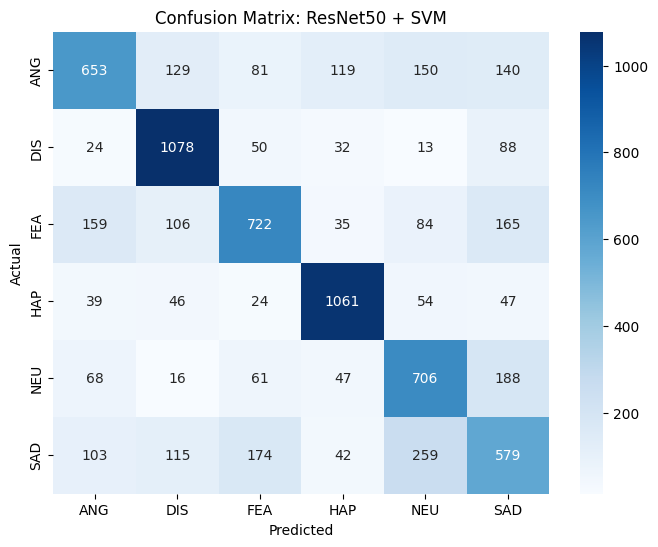

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Vẽ biểu đồ quá trình huấn luyện (Minh chứng cho Scheduler)
def plot_training_history(df):
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Trục trái: Loss và Accuracy
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss/Score')
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue', linestyle='--')
    ax1.plot(df['epoch'], df['val_loss'], label='Val Loss', color='red')
    ax1.plot(df['epoch'], df['val_acc'], label='Val Acc', color='green')
    ax1.legend(loc='upper left')

    # Trục phải: Learning Rate
    ax2 = ax1.twinx()
    ax2.set_ylabel('Learning Rate', color='purple')
    ax2.plot(df['epoch'], df['lr'], label='LR', color='purple', alpha=0.3)
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor='purple')

    plt.title('Training History with Learning Rate Decay')
    plt.show()

plot_training_history(history_df)

# 2. Tải mô hình tốt nhất đã lưu trong lúc train
model.load_state_dict(torch.load('best_resnet50_emotion.pth'))
model.to(device)

# 3. Trích xuất đặc trưng sâu (Deep Features) - ResNet50 trả về 2048 chiều
print("--- Đang trích xuất đặc trưng từ ResNet-50 (Best Model) ---")
X_train_feat, y_train_feat = extract_deep_features(model, train_loader, device)
X_val_feat, y_val_feat = extract_deep_features(model, val_loader, device)

# 4. Chuẩn hóa và huấn luyện SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)

print(f"--- Đang huấn luyện SVM (Kernel RBF) trên vector {X_train_scaled.shape[1]} chiều ---")
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_classifier.fit(X_train_scaled, y_train_feat)

# 5. Dự đoán và Đánh giá chi tiết
y_pred_svm = svm_classifier.predict(X_val_scaled)

# Lưu ý: 'emotions' là list tên cảm xúc của bạn (ví dụ: ['ANG', 'DIS', 'FEA', ...])
print("\n📊 HYBRID DCNN-SVM EVALUATION REPORT")
print(classification_report(y_val_feat, y_pred_svm, target_names=emotions, digits=4))

# 6. Vẽ Confusion Matrix để đưa vào báo cáo
cm = confusion_matrix(y_val_feat, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: ResNet50 + SVM')
plt.show()

In [ ]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def print_macro_metrics(y_true, y_pred, title="Evaluation"):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n📊 {title}")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Precision (Macro)  : {precision:.4f}")
    print(f"Recall (Macro)     : {recall:.4f}")
    print(f"F1-score (Macro)   : {f1:.4f}")

    return acc, precision, recall, f1


In [ ]:
# --- Evaluate CNN ---
model.eval()
y_true_cnn = []
y_pred_cnn = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        y_true_cnn.extend(labels.numpy())
        y_pred_cnn.extend(preds.cpu().numpy())

print_macro_metrics(
    y_true_cnn,
    y_pred_cnn,
    title="ResNet-50 Fine-tuned (Softmax Head)"
)



📊 ResNet-50 Fine-tuned (Softmax Head)
Accuracy           : 0.6637
Precision (Macro)  : 0.6575
Recall (Macro)     : 0.6634
F1-score (Macro)   : 0.6584


(0.6636717178490009,
 0.6574573231618576,
 0.6634374981477528,
 0.6584274675627592)

In [ ]:
# --- Evaluate SVM ---
y_pred_svm = svm_classifier.predict(X_val_scaled)

print_macro_metrics(
    y_val_feat,
    y_pred_svm,
    title="ResNet-50 Deep Features + SVM (RBF)"
)



📊 ResNet-50 Deep Features + SVM (RBF)
Accuracy           : 0.6436
Precision (Macro)  : 0.6381
Recall (Macro)     : 0.6434
F1-score (Macro)   : 0.6380


(0.6435563899691565, 0.6380964725074686, 0.6433980769013847, 0.63795648934726)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
print("--- Đang huấn luyện MLP Classifier ---")

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(512, 128),  # rất hợp với ResNet features
    activation='relu',
    solver='adam',
    alpha=1e-4,                     # L2 regularization
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

mlp_classifier.fit(X_train_scaled, y_train_feat)


--- Đang huấn luyện MLP Classifier ---
Iteration 1, loss = 1.22165092
Validation score: 0.531230
Iteration 2, loss = 0.82267188
Validation score: 0.522397
Iteration 3, loss = 0.49967384
Validation score: 0.514826
Iteration 4, loss = 0.21608814
Validation score: 0.500315
Iteration 5, loss = 0.07361345
Validation score: 0.517350
Iteration 6, loss = 0.02090352
Validation score: 0.516088
Iteration 7, loss = 0.00810670
Validation score: 0.517350
Iteration 8, loss = 0.00470404
Validation score: 0.517981
Iteration 9, loss = 0.00436283
Validation score: 0.516719
Iteration 10, loss = 0.00290536
Validation score: 0.519874
Iteration 11, loss = 0.00319310
Validation score: 0.514826
Iteration 12, loss = 0.00335556
Validation score: 0.519243
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPClassifier(batch_size=128, early_stopping=True,
              hidden_layer_sizes=(512, 128), learning_rate='adaptive',
              max_iter=300, random_state=42, verbose=True)

In [ ]:

y_pred_mlp = mlp_classifier.predict(X_val_scaled)

print("\n📊 MLP EVALUATION ON RESNET-50 FEATURES")
print(classification_report(
    y_val_feat,
    y_pred_mlp,
    target_names=emotions,
    digits=4
))



📊 MLP EVALUATION ON RESNET-50 FEATURES
              precision    recall  f1-score   support

         ANG     0.6522    0.5204    0.5789      1272
         DIS     0.7579    0.8163    0.7861      1285
         FEA     0.6466    0.5500    0.5944      1271
         HAP     0.7864    0.8371    0.8110      1271
         NEU     0.5053    0.7081    0.5897      1086
         SAD     0.4701    0.4072    0.4364      1272

    accuracy                         0.6385      7457
   macro avg     0.6364    0.6399    0.6327      7457
weighted avg     0.6399    0.6385    0.6341      7457



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
cm = confusion_matrix(y_val_feat, y_pred_mlp)


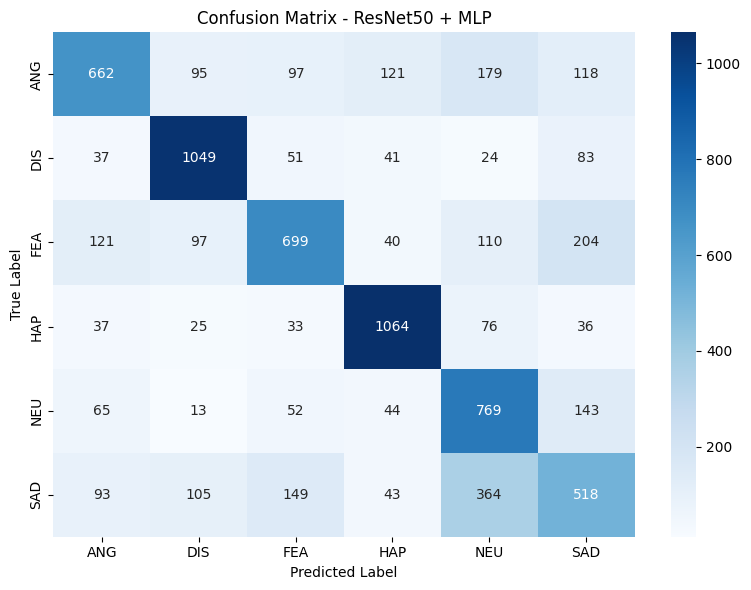

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotions,
    yticklabels=emotions
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50 + MLP")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotions,
    yticklabels=emotions
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50 + MLP")
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=300)
plt.close()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/resnet_svm_project"
!mkdir -p $PROJECT_DIR


In [ ]:
torch.save(model.state_dict(), f"{PROJECT_DIR}/resnet50_best_emotion.pth")


In [ ]:
!rsync -av --progress \
  --exclude=drive \
  /content/ $PROJECT_DIR/


sending incremental file list
./
best_resnet50_emotion.pth
     98,564,139 100%  101.04MB/s    0:00:00 (xfr#1, to-chk=31/33)
confusion_matrix_mlp.png
        156,956 100%  159.33kB/s    0:00:00 (xfr#2, to-chk=30/33)
scaler.pkl
         49,767 100%   50.52kB/s    0:00:00 (xfr#3, to-chk=29/33)
svm_rbf.pkl
    220,212,387 100%   90.72MB/s    0:00:02 (xfr#4, to-chk=28/33)
training_history_resnet50_mlp.csv
          7,634 100%   23.67kB/s    0:00:00 (xfr#5, to-chk=27/33)
.config/
.config/.last_opt_in_prompt.yaml
              3 100%    0.01kB/s    0:00:00 (xfr#6, to-chk=23/33)
.config/.last_survey_prompt.yaml
             36 100%    0.11kB/s    0:00:00 (xfr#7, to-chk=22/33)
.config/.last_update_check.json
            135 100%    0.41kB/s    0:00:00 (xfr#8, to-chk=21/33)
.config/active_config
              7 100%    0.02kB/s    0:00:00 (xfr#9, to-chk=20/33)
.config/config_sentinel
              0 100%    0.00kB/s    0:00:00 (xfr#10, to-chk=19/33)
.config/default_configs.db
         12,288 10